## Gauss-Seidel method 

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve


In [25]:

def get_gradients_and_divergence(img_channel):
    """
    Computes forward difference gradients and the resulting 
    backward difference divergence for a single channel.
    """
    h, w = img_channel.shape
    img_padded = img_channel.astype(np.float64)
    
    # 1. Forward differences for gradients
    # Pad right and bottom edges by duplicating to handle boundaries smoothly
    grad_x = np.zeros_like(img_padded)
    grad_y = np.zeros_like(img_padded)
    
    grad_x[:, :-1] = img_padded[:, 1:] - img_padded[:, :-1]
    grad_y[:-1, :] = img_padded[1:, :] - img_padded[:-1, :]
    
    # 2. Backward differences for Divergence: div = d(gx)/dx + d(gy)/dy
    div_x = np.zeros_like(grad_x)
    div_y = np.zeros_like(grad_y)
    
    div_x[:, 1:] = grad_x[:, 1:] - grad_x[:, :-1]
    div_y[1:, :] = grad_y[1:, :] - grad_y[:-1, :]
    
    div = div_x + div_y
    return grad_x, grad_y, div

def get_gradients_and_divergence_rgb(color_image):
    """Обчислює диверсію окремо для Кожного з 3-х каналів RGB."""
    channels = cv2.split(color_image)
    div_channels = []
    
    for c in range(3):
        # Використовуємо вашу функцію get_gradients_and_divergence для ОДНОГО каналу
        _, _, div_c = get_gradients_and_divergence(channels[c])
        div_channels.append(div_c)
        
    # Зшиваємо назад у 3-канальний масив дивергенцій
    return cv2.merge(div_channels)

In [ ]:
def poisson_reconstruct_seidel(target_img, div, max_iter=500, tolerance=1e-4):
    """Відновлення одного каналу методом Гаусса-Зейделя з умовами Діріхле."""
    h, w = target_img.shape
    # Ініціалізуємо матрицю початковим зображенням (границі залишаються фіксованими)
    I = target_img.copy().astype(np.float64)
    
    for _ in range(max_iter):
        I_old = I.copy()
        # Внутрішні пікселі обробляємо послідовно
        for y in range(1, h - 1):
            for x in range(1, w - 1):
                I[y, x] = 0.25 * (I[y, x+1] + I[y, x-1] + I[y+1, x] + I[y-1, x] - div[y, x])
                
        # Перевірка збіжності
        if np.max(np.abs(I - I_old)) < tolerance:
            break
            
    return np.clip(I, 0, 255).astype(np.uint8)

In [29]:
def poisson_reconstruct_seidel_fast(target_img, div, max_iter=500, tolerance=1e-4):
    """
    Швидкий метод Гаусса-Зейделя (Red-Black) без помилок індексації.
    Оновлення координат відбувається через прямі зміщення знайдених індексів.
    """
    h, w = target_img.shape
    I = target_img.copy().astype(np.float64)
    
    # Створюємо маски для шахівниці
    y, x = np.indices((h, w))
    internal_mask = (y > 0) & (y < h - 1) & (x > 0) & (x < w - 1)
    checkerboard = (y + x) % 2 == 0
    
    red_mask = internal_mask & checkerboard
    black_mask = internal_mask & (~checkerboard)
    
    # Знаходимо фіксовані 2D координати для швидкого NumPy доступу
    r_y, r_x = np.where(red_mask)
    b_y, b_x = np.where(black_mask)
    
    for _ in range(max_iter):
        I_old = I.copy()
        
        # --- Крок 1: Оновлюємо ЧЕРВОНІ пікселі ---
        # Використовуємо сусідів: справа (r_x+1), зліва (r_x-1), знизу (r_y+1), зверху (r_y-1)
        I[red_mask] = 0.25 * (
            I[r_y, r_x + 1] + 
            I[r_y, r_x - 1] + 
            I[r_y + 1, r_x] + 
            I[r_y - 1, r_x] - 
            div[red_mask]
        )
        
        # --- Крок 2: Оновлюємо ЧОРНІ пікселі ---
        # Використовуємо щойно оновлені значення червоних сусідів
        I[black_mask] = 0.25 * (
            I[b_y, b_x + 1] + 
            I[b_y, b_x - 1] + 
            I[b_y + 1, b_x] + 
            I[b_y - 1, b_x] - 
            div[black_mask]
        )
        
        # Перевірка збіжності
        if np.max(np.abs(I - I_old)) < tolerance:
            break
            
    return np.clip(I, 0, 255).astype(np.uint8)

def poisson_reconstruct_rgb(target_img, div_rgb, max_iter=500, tolerance=1e-4):
    """Поканальне відновлення кольорового зображення."""
    img_channels = cv2.split(target_img)
    div_channels = cv2.split(div_rgb)
    
    reconstructed_channels = []
    
    for c in range(3):
        recon_c = poisson_reconstruct_seidel_fast(
            img_channels[c], 
            div_channels[c], 
            max_iter=max_iter, 
            tolerance=tolerance
        )
        reconstructed_channels.append(recon_c)
        
    return cv2.merge(reconstructed_channels)

## Computing reconstruction error 

In [33]:
def run_exact_recovery_test(orig, recon):
    """Обчислює матрицю помилок та середнє відхилення між двома зображеннями."""
    # Переводимо в float64, щоб уникнути переповнення uint8 при відніманні
    diff_matrix = np.abs(orig.astype(np.float64) - recon.astype(np.float64))
    
    mse = np.mean(diff_matrix ** 2)
    max_diff = np.max(diff_matrix)
    
    print("====== EXACT RECOVERY TEST ======")
    print(f"Mean Squared Error (MSE): {mse:.6f}")
    print(f"Maximum Pixel Difference: {max_diff:.2f}")
    print("=================================")
    return diff_matrix

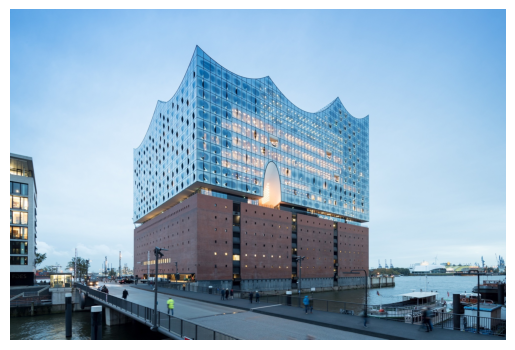

In [4]:
image1 = cv2.imread("data/Gamburg_philarmonie_on_Elbe.jpg")
image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
plt.imshow(image1)
plt.axis("off")
plt.show()

### Corruption 1: noising

In [ ]:
# Quick code snippet to add Gaussian Noise
noise_image1 = np.random.normal(0, 50, image1.shape).astype(np.float64)
noisy_image1 = np.clip(image1.astype(np.float64) + noise_image1, 0, 255).astype(np.uint8)

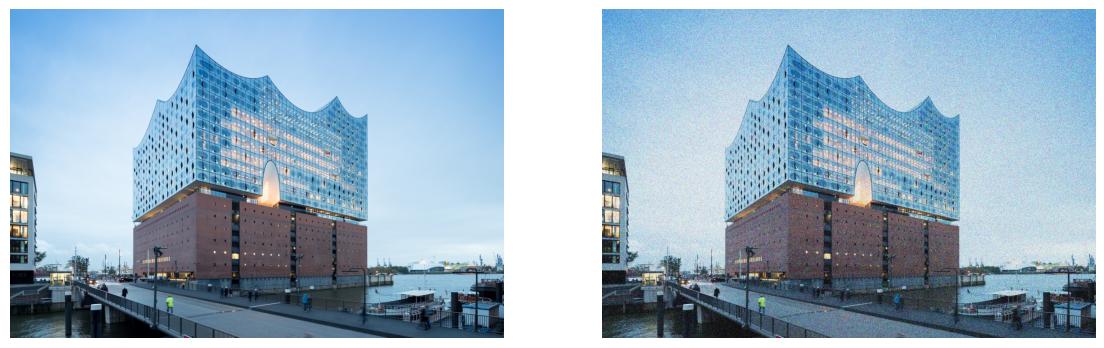

In [11]:
plt.figure(figsize=(14, 12))
plt.subplot(121), plt.imshow(image1)
plt.subplot(122), plt.imshow(noisy_image1)

plt.subplot(121).axis("off")
# plt.subplot(121).subtitle("Gaussian noisied")
plt.subplot(122).axis("off")

plt.show()

In [30]:
div = get_gradients_and_divergence_rgb(image1)
reconstructed_noisy_image1 = poisson_reconstruct_rgb(noisy_image1, div)


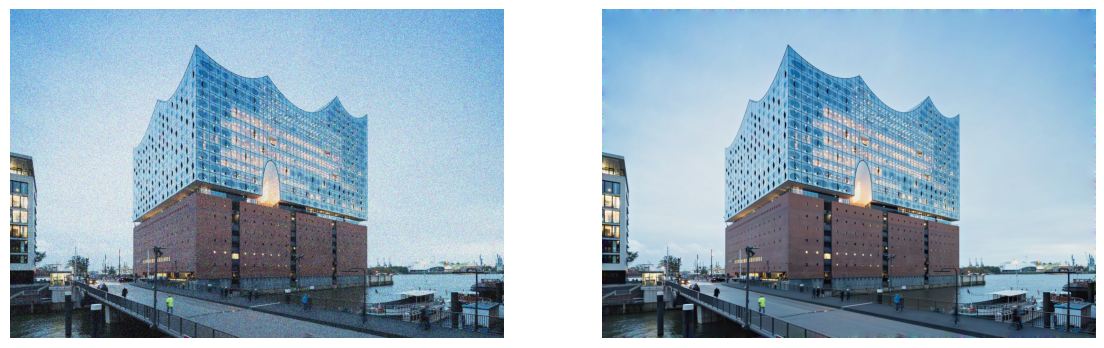

In [31]:
plt.figure(figsize=(14, 12))
plt.subplot(121), plt.imshow(noisy_image1)
plt.subplot(122), plt.imshow(reconstructed_noisy_image1)

plt.subplot(121).axis("off")
# plt.subplot(121).subtitle("Gaussian noisied")
plt.subplot(122).axis("off")

plt.show()

In [35]:
diff_matrix = run_exact_recovery_test(image1, reconstructed_noisy_image1)

====== EXACT RECOVERY TEST ======
Mean Squared Error (MSE): 64.293670
Maximum Pixel Difference: 190.00


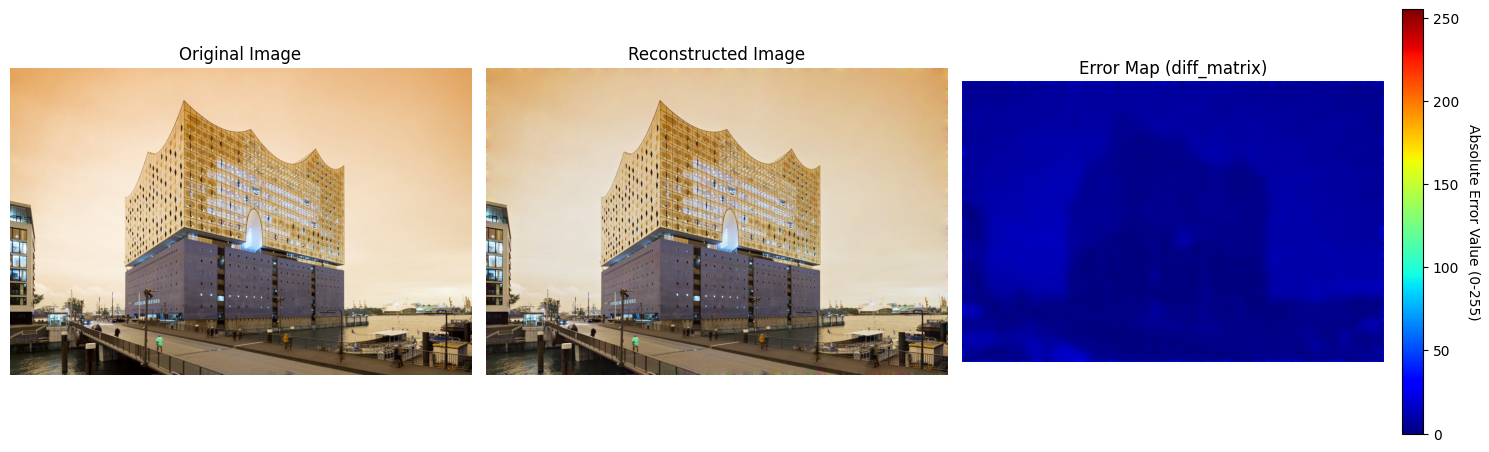

Максимальна помилка в одному пікселі: 112.00
Середня абсолютна помилка (MAE): 5.8086


In [36]:

def visualize_recovery_error(original, reconstructed):
    """
    Обчислює та візуалізує карту помилок між двома зображеннями.
    Підтримує як кольорові, так і сірі зображення.
    """
    # 1. Переводимо в колірний простір RGB для відображення в matplotlib (якщо картинка кольорова)
    if len(original.shape) == 3:
        orig_disp = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
        recon_disp = cv2.cvtColor(reconstructed, cv2.COLOR_BGR2RGB)
        # Для кольорових картинок беремо середню помилку по трьох каналах (R,G,B)
        diff_matrix = np.mean(np.abs(original.astype(np.float64) - reconstructed.astype(np.float64)), axis=2)
    else:
        orig_disp = original
        recon_disp = reconstructed
        diff_matrix = np.abs(original.astype(np.float64) - reconstructed.astype(np.float64))
    
    # 2. Малюємо триптих для лабораторного звіту
    plt.figure(figsize=(15, 5))
    
    # Оригінал
    plt.subplot(1, 3, 1)
    plt.imshow(orig_disp, cmap='gray' if len(original.shape) == 2 else None)
    plt.title("Original Image")
    plt.axis('off')
    
    # Результат вашого розв'язувача Пуассона
    plt.subplot(1, 3, 2)
    plt.imshow(recon_disp, cmap='gray' if len(original.shape) == 2 else None)
    plt.title("Reconstructed Image")
    plt.axis('off')
    
    # Карта помилок (diff_matrix)
    plt.subplot(1, 3, 3)
    # Зберігаємо результат у змінну im, щоб додати шкалу оцінки яскравості помилки
    im = plt.imshow(diff_matrix, cmap='jet', vmin=0, vmax=255)
    plt.title("Error Map (diff_matrix)")
    plt.axis('off')
    
    # Додаємо праворуч кольорову шкалу (Colorbar), яка показує величину помилки в пікселях
    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label('Absolute Error Value (0-255)', rotation=270, labelpad=15)
    
    plt.tight_layout()
    plt.show()
    
    # Виводимо текстові метрики в консоль
    print(f"Максимальна помилка в одному пікселі: {np.max(diff_matrix):.2f}")
    print(f"Середня абсолютна помилка (MAE): {np.mean(diff_matrix):.4f}")

visualize_recovery_error(image1, reconstructed_noisy_image1)

### corruption 2: boosted grads

In [ ]:
# 1. Рахуємо чисті градієнти для КОЛЬОРОВОГО зображення (поканально)
channels = cv2.split(image1)
boosted_div_channels = []

# Коефіцієнт маніпуляції: 1.5 означає зробити всі текстури значно чіткішими
contrast_factor = 1.5 

for c in range(3):
    # Отримуємо чисті градієнти для одного каналу
    grad_x, grad_y, _ = get_gradients_and_divergence(channels[c])
    
    # СПОТВОРЕННЯ / МАНІПУЛЯЦІЯ: Навмисно змінюємо інструкції градієнтів
    manipulated_grad_x = grad_x * contrast_factor
    manipulated_grad_y = grad_y * contrast_factor
    
    # Перераховуємо дивергенцію з модифікованих градієнтів (використовуємо надійний зріз без np.roll)
    div_x = np.zeros_like(manipulated_grad_x)
    div_y = np.zeros_like(manipulated_grad_y)
    
    div_x[:, 1:] = manipulated_grad_x[:, 1:] - manipulated_grad_x[:, :-1]
    div_y[1:, :] = manipulated_grad_y[1:, :] - manipulated_grad_y[:-1, :]
    
    boosted_div_channels.append(div_x + div_y)

# Зшиваємо модифіковану дивергенцію назад у 3 канали
boosted_div_rgb = cv2.merge(boosted_div_channels)

# 2. ВІДНОВЛЕННЯ / ОЖИВЛЕННЯ
# Ми даємо алгоритму оригінальне image1 ТІЛЬКИ як джерело країв (граничних умов Діріхле).
# Весь центр буде збудований заново по "шалених" інструкціях з boosted_div_rgb.
reconstructed_boosted_grads_image1 = poisson_reconstruct_rgb(image1, boosted_div_rgb, max_iter=300)


In [ ]:
plt.figure(figsize=(14, 12))
plt.subplot(121), plt.imshow(image1)
plt.subplot(122), plt.imshow(reconstructed_boosted_grads_image1)

plt.subplot(121).axis("off")
plt.subplot(122).axis("off")

plt.show()

In [ ]:
run_exact_recovery_test(image1, reconstructed_boosted_grads_image1)

### Corruption 3: erased regions

In [32]:
# 1. Створюємо зіпсоване зображення з чорним квадратом по центру
spoiled_inpainting = image1.copy()
h, w, _ = spoiled_inpainting.shape
cy, cx = h // 2, w // 2
r = min(h, w) // 4  # Радіус пошкодження

# Малюємо чорну заглушку (це наші граничні умови для діри всередині)
spoiled_inpainting[cy-r:cy+r, cx-r:cx+r] = 0

# 2. Рахуємо чисті градієнти з ОРИГІНАЛУ, але занулюємо їх всередині діри
div_inpainting_channels = []
for c in range(3):
    grad_x, grad_y, _ = get_gradients_and_divergence(cv2.split(image1)[c])
    
    # Занулюємо інструкції змін текстури всередині квадрата
    grad_x[cy-r:cy+r, cx-r:cx+r] = 0
    grad_y[cy-r:cy+r, cx-r:cx+r] = 0
    
    # Перераховуємо дивергенцію
    dx = np.zeros_like(grad_x)
    dy = np.zeros_like(grad_y)
    dx[:, 1:] = grad_x[:, 1:] - grad_x[:, :-1]
    dy[1:, :] = grad_y[1:, :] - grad_y[:-1, :]
    div_inpainting_channels.append(dx + dy)

div_inpainting_rgb = cv2.merge(div_inpainting_channels)

# 3. Відновлення (запускаємо швидкий Sparse, бо Зейдель тут застрягне на годину)
reconstructed_inpainting = poisson_reconstruct_rgb(spoiled_inpainting, div_inpainting_rgb)

In [ ]:
plt.figure(figsize=(14, 12))
plt.subplot(121), plt.imshow(spoiled_inpainting)
plt.subplot(122), plt.imshow(reconstructed_inpainting)

plt.subplot(121).axis("off")
plt.subplot(122).axis("off")

plt.show()

In [ ]:
run_exact_recovery_test(image1, reconstructed_inpainting)

### Corruption 4: Gaussian blur

In [ ]:
# 1. Сильно розмиваємо оригінальне зображення
blurred_image = cv2.GaussianBlur(image1, (25, 25), 0)

# 2. Знімаємо градієнти з РОЗМИТОЇ картинки (там майже немає різких перепадів)
div_blurred_rgb = get_gradients_and_divergence_rgb(image1)

# 3. Намагаємося "відновити" зображення.
# Як граничні умови (рамку) передаємо чистий оригінал image1, але поле градієнтів — розмите.
reconstructed_blur = poisson_reconstruct_rgb(blurred_image, div_blurred_rgb)

In [ ]:
plt.figure(figsize=(14, 12))
plt.subplot(121), plt.imshow(blurred_image)
plt.subplot(122), plt.imshow(reconstructed_blur)

plt.subplot(121).axis("off")
plt.subplot(122).axis("off")

plt.show()

In [ ]:
run_exact_recovery_test(image1, reconstructed_blur)

# Scipy-sparse method

In [37]:
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve


In [38]:
def poisson_reconstruct_sparse_channel(target_img_c, div_c):
    """Прямий розв'язок рівняння Пуассона для одного каналу за допомогою SciPy."""
    h, w = target_img_c.shape
    n = h * w
    A = lil_matrix((n, n), dtype=np.float64)
    b = np.zeros(n, dtype=np.float64)
    
    img_id = lambda y, x: y * w + x
    
    for y in range(h):
        for x in range(w):
            idx = img_id(y, x)
            if y == 0 or y == h - 1 or x == 0 or x == w - 1:
                A[idx, idx] = 1.0
                b[idx] = target_img_c[y, x]
            else:
                A[idx, idx] = -4.0
                A[idx, img_id(y, x + 1)] = 1.0
                A[idx, img_id(y, x - 1)] = 1.0
                A[idx, img_id(y + 1, x)] = 1.0
                A[idx, img_id(y - 1, x)] = 1.0
                b[idx] = div_c[y, x]
                
    return np.clip(spsolve(A.tocsr(), b).reshape((h, w)), 0, 255).astype(np.uint8)

def poisson_reconstruct_sparse_rgb(target_img, div_rgb):
    """Поканальний швидкий розв'язувач для кольорових зображень."""
    img_channels = cv2.split(target_img)
    div_channels = cv2.split(div_rgb)
    recon_channels = [poisson_reconstruct_sparse_channel(img_channels[c], div_channels[c]) for c in range(3)]
    return cv2.merge(recon_channels)

In [ ]:
div = get_gradients_and_divergence_rgb(image1)
reconstructed_noisy_image1 = poisson_reconstruct_sparse_rgb(noisy_image1, div)


In [ ]:
diff_matrix = run_exact_recovery_test(image1, reconstructed_noisy_image1)
visualize_recovery_error(image1, reconstructed_noisy_image1)

In [ ]:
plt.figure(figsize=(14, 12))
plt.subplot(121), plt.imshow(noisy_image1)
plt.subplot(122), plt.imshow(reconstructed_noisy_image1)

plt.subplot(121).axis("off")
# plt.subplot(121).subtitle("Gaussian noisied")
plt.subplot(122).axis("off")

plt.show()

## Poisson blending

In [ ]:
def compute_divergence(grad_x, grad_y):
    """Обчислення дивергенції градієнтного поля."""
    # div = d(grad_x)/d x + d(grad_y)/dy
    # Використовуємо зворотні різниці для дивергенції, якщо для градієнтів бралися прямі
    dx = grad_x - np.roll(grad_x, 1, axis=1)
    dy = grad_y - np.roll(grad_y, 1, axis=0)
    return dx + dy


def poisson_blend_rgb(source, target, mask, offset=(0, 0), method='sparse'):
    """
    Повне безшовне вставлення образу в target по масці.
    offset: (dy, dx) — куди саме вставляти лівий верхній кут образу на target.
    """
    dy, dx = offset
    h_s, w_s = source.shape[:2]
    
    # Вирізаємо робочу область з target
    target_roi = target[dy:dy+h_s, dx:dx+w_s].copy()
    
    # Створюємо вихідну область для результату
    blended_roi = np.zeros_like(target_roi)
    
    # Обробляємо кожен канал (R, G, B) окремо
    for c in range(3):
        s_c = source[:, :, c].astype(np.float64)
        t_c = target_roi[:, :, c].astype(np.float64)
        
        # 1. Обчислюємо градієнти джерела (source)
        # Прямі різниці
        grad_x = np.roll(s_c, -1, axis=1) - s_c
        grad_y = np.roll(s_c, -1, axis=0) - s_c
        
        # 2. Обчислюємо дивергенцію по цих градієнтах
        div = compute_divergence(grad_x, grad_y)
        
        # 3. Модифікуємо дивергенцію: всередині маски — значення джерела, 
        # поза маскою (на границі Діріхле) — фіксуємо значення target
        # Для цього формуємо матрицю умов для алгоритму розв'язку
        
        if method == 'seidel':
            # Для Зейделя ми передаємо div і модифікуємо алгоритм під маску
            h, w = t_c.shape
            I = t_c.copy()
            for _ in range(200): # менше ітерацій для швидкості демонстрації
                for y in range(1, h - 1):
                    for x in range(1, w - 1):
                        if mask[y, x] > 0: # Якщо всередині маски — розв'язуємо Пуассона
                            I[y, x] = 0.25 * (I[y, x+1] + I[y, x-1] + I[y+1, x] + I[y-1, x] - div[y, x])
                        # Якщо поза маскою — значення лишається з target (умова Діріхле)
            blended_roi[:, :, c] = np.clip(I, 0, 255).astype(np.uint8)
            
        else: # Метод Sparse (SciPy)
            h, w = t_c.shape
            n = h * w
            A = lil_matrix((n, n), dtype=np.float64)
            b = np.zeros(n, dtype=np.float64)
            img_id = lambda y, x: y * w + x
            
            for y in range(h):
                for x in range(w):
                    idx = img_id(y, x)
                    # Границя маски або границя всього зображення
                    if mask[y, x] == 0 or y == 0 or y == h - 1 or x == 0 or x == w - 1:
                        A[idx, idx] = 1.0
                        b[idx] = t_c[y, x]
                    else:
                        A[idx, idx] = -4.0
                        A[idx, img_id(y, x + 1)] = 1.0
                        A[idx, img_id(y, x - 1)] = 1.0
                        A[idx, img_id(y + 1, x)] = 1.0
                        A[idx, img_id(y - 1, x)] = 1.0
                        b[idx] = div[y, x]
            
            A = A.tocsr()
            x_sol = spsolve(A, b)
            blended_roi[:, :, c] = np.clip(x_sol.reshape((h, w)), 0, 255).astype(np.uint8)
            
    # Вставляємо оброблену область назад у фінальне зображення
    final_img = target.copy()
    final_img[dy:dy+h_s, dx:dx+w_s] = blended_roi
    return final_img

In [ ]:
# Створюємо образ для вставлення (наприклад, зелене коло на білому фоні)
source_image = np.ones((100, 100, 3), dtype=np.uint8) * 255
cv2.circle(source_image, (50, 50), 30, (50, 200, 50), -1)

# Створюємо бінарну маску кола
mask = np.zeros((100, 100), dtype=np.uint8)
cv2.circle(mask, (50, 50), 30, 255, -1)

# Виконуємо безшовне вставлення за допомогою швидкого SciPy Sparse методу
result = poisson_blend_rgb(source_image, image1, mask, offset=(50, 50), method='sparse')



In [ ]:
# Візуалізація результату
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(source_image, cv2.COLOR_BGR2RGB))
plt.title("Source (Образ)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
plt.title("Target (Фон)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Poisson Blending")
plt.axis('off')

plt.tight_layout()
plt.show()